# Cereal Data Preprocessing and Exploration
This notebook performs initial data preprocessing and exploratory data analysis (EDA) on the Cereals dataset.

We will:
1. Load the dataset and inspect its structure.
2. Calculate overall summary statistics (mean, median, min, max, standard deviation).
3. Analyze aggregate statistics by grouping data (e.g., by manufacturer).
4. Visualize the data to find insights.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Set styling for plots
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

## 1. Loading the Dataset
We load the dataset from the CSV file and look at the first few rows.

In [8]:
# Load the dataset
df = pd.read_csv("M1 & M4 - Cereals - Cereals.csv")

# Display the first 5 rows
df.head()

,name,mfr,type,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating
0,100%_Bran,N,C,70,4,1,130,10.0,5.0,6.0,280.0,25,3,1.0,0.33,68.402973
1,100%_Natural_Bran,Q,C,120,3,5,15,2.0,8.0,8.0,135.0,0,3,1.0,1.00,33.983679
2,All-Bran,K,C,70,4,1,260,9.0,7.0,5.0,320.0,25,3,1.0,0.33,59.425505
3,All-Bran_with_Extra_Fiber,K,C,50,4,0,140,14.0,8.0,0.0,330.0,25,3,1.0,0.50,93.704912
4,Almond_Delight,R,C,110,2,2,200,1.0,14.0,8.0,NaN,25,3,1.0,0.75,34.384843


## 2. General Data Information
Let's check the columns, data types, and check for missing values.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      77 non-null     object 
 1   mfr       77 non-null     object 
 2   type      77 non-null     object 
 3   calories  77 non-null     int64  
 4   protein   77 non-null     int64  
 5   fat       77 non-null     int64  
 6   sodium    77 non-null     int64  
 7   fiber     77 non-null     float64
 8   carbo     76 non-null     float64
 9   sugars    76 non-null     float64
 10  potass    75 non-null     float64
 11  vitamins  77 non-null     int64  
 12  shelf     77 non-null     int64  
 13  weight    77 non-null     float64
 14  cups      77 non-null     float64
 15  rating    77 non-null     float64
dtypes: float64(7), int64(6), object(3)
memory usage: 9.8+ KB


## 3. Summary Statistics
Let's compute the overall summary statistics for all numeric columns in the dataset.

In [4]:
# Compute statistics individually for numerical columns
numerical_df = df.select_dtypes(include=[np.number])

mean = numerical_df.mean()
median = numerical_df.median()
minimum = numerical_df.min()
maximum = numerical_df.max()
std_dev = numerical_df.std()

# Combine them into a single dataframe for clean display
summary_stats = pd.DataFrame({
    'Mean': mean,
    'Median': median,
    'Min': minimum,
    'Max': maximum,
    'Std Dev': std_dev
})

summary_stats

,Mean,Median,Min,Max,Std Dev
calories,106.883117,110.000000,50.000000,160.000000,19.484119
protein,2.545455,3.000000,1.000000,6.000000,1.094790
fat,1.012987,1.000000,0.000000,5.000000,1.006473
sodium,159.675325,180.000000,0.000000,320.000000,83.832295
fiber,2.151948,2.000000,0.000000,14.000000,2.383364
carbo,14.802632,14.500000,5.000000,23.000000,3.907326
sugars,7.026316,7.000000,0.000000,15.000000,4.378656
potass,98.666667,90.000000,15.000000,330.000000,70.410636
vitamins,28.246753,25.000000,0.000000,100.000000,22.342523
shelf,2.207792,2.000000,1.000000,3.000000,0.832524


We can also use pandas' built-in `describe()` function to get a comprehensive summary of statistics:

In [5]:
df.describe()

,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating
count,77.000000,77.000000,77.000000,77.000000,77.000000,76.000000,76.000000,75.000000,77.000000,77.000000,77.000000,77.000000,77.000000
mean,106.883117,2.545455,1.012987,159.675325,2.151948,14.802632,7.026316,98.666667,28.246753,2.207792,1.029610,0.821039,42.665705
std,19.484119,1.094790,1.006473,83.832295,2.383364,3.907326,4.378656,70.410636,22.342523,0.832524,0.150477,0.232716,14.047289
min,50.000000,1.000000,0.000000,0.000000,0.000000,5.000000,0.000000,15.000000,0.000000,1.000000,0.500000,0.250000,18.042851
25%,100.000000,2.000000,0.000000,130.000000,1.000000,12.000000,3.000000,42.500000,25.000000,1.000000,1.000000,0.670000,33.174094
50%,110.000000,3.000000,1.000000,180.000000,2.000000,14.500000,7.000000,90.000000,25.000000,2.000000,1.000000,0.750000,40.400208
75%,110.000000,3.000000,2.000000,210.000000,3.000000,17.000000,11.000000,120.000000,25.000000,3.000000,1.000000,1.000000,50.828392
max,160.000000,6.000000,5.000000,320.000000,14.000000,23.000000,15.000000,330.000000,100.000000,3.000000,1.500000,1.500000,93.704912


## 4. Grouping and Aggregating Data
The original code grouped the dataset by cereal `name`:
```python
Newdf = df.groupby("name")
```
Since each cereal has a unique `name` in the dataset, grouping by `name` results in groups of size 1. This means calculating the mean/median/std per cereal name will just return the original row values.

To get meaningful grouped statistics, it is more useful to group by manufacturer (`mfr`) or cereal type (`type`).

Let's first map the manufacturer codes to their actual names for readability:
- **N**: Nabisco
- **Q**: Quaker Oats
- **K**: Kelloggs
- **R**: Ralston Purina
- **G**: General Mills
- **P**: Post
- **A**: American Home Foods

In [6]:
# Map manufacturer codes to full names
mfr_map = {
    'N': 'Nabisco',
    'Q': 'Quaker Oats',
    'K': 'Kelloggs',
    'R': 'Ralston Purina',
    'G': 'General Mills',
    'P': 'Post',
    'A': 'American Home Foods'
}
df['manufacturer_name'] = df['mfr'].map(mfr_map)

# Group by manufacturer and compute mean stats
mfr_grouped = df.groupby('manufacturer_name')
mfr_grouped.mean(numeric_only=True)

,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating
manufacturer_name,,,,,,,,,,,,,
American Home Foods,100.000000,4.000000,1.000000,0.000000,0.000000,16.000000,3.000000,95.000000,25.000000,2.000000,1.000000,1.000000,54.850917
General Mills,111.363636,2.318182,1.363636,200.454545,1.272727,14.727273,7.954545,85.227273,35.227273,2.136364,1.049091,0.875000,34.485852
Kelloggs,108.695652,2.652174,0.608696,174.782609,2.739130,15.130435,7.565217,103.043478,34.782609,2.347826,1.077826,0.796087,44.038462
Nabisco,86.666667,2.833333,0.166667,37.500000,4.000000,16.000000,1.833333,145.000000,8.333333,1.666667,0.971667,0.778333,67.968567
Post,108.888889,2.444444,0.888889,146.111111,2.777778,13.222222,8.777778,113.888889,25.000000,2.444444,1.064444,0.714444,41.705744
Quaker Oats,95.000000,2.625000,1.750000,92.500000,1.337500,11.571429,6.142857,74.375000,12.500000,2.375000,0.875000,0.823750,42.915990
Ralston Purina,115.000000,2.500000,1.250000,198.125000,1.875000,17.625000,6.125000,102.142857,25.000000,2.000000,1.000000,0.871250,41.542997


## 5. Visualizing the Insights
Let's plot the average nutritional rating of cereals by manufacturer to see which one makes the highest-rated (healthiest) options on average.

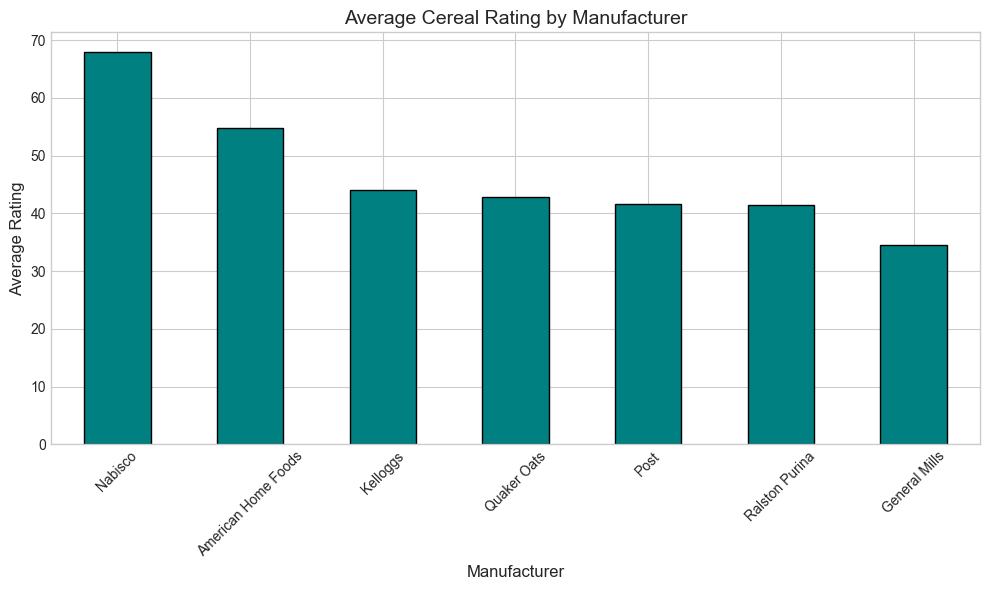

In [7]:
# Average rating by manufacturer
avg_rating = mfr_grouped['rating'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
avg_rating.plot(kind='bar', color='teal', edgecolor='black')
plt.title('Average Cereal Rating by Manufacturer', fontsize=14)
plt.ylabel('Average Rating', fontsize=12)
plt.xlabel('Manufacturer', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()